In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [2]:
# Load all datasets
users = pd.read_csv("raw_data/users.csv")
movies = pd.read_csv("raw_data/movies.csv")
watch = pd.read_csv("raw_data/watch_history.csv")
recommendations = pd.read_csv("raw_data/recommendation_logs.csv")
search = pd.read_csv("raw_data/search_logs.csv")
reviews = pd.read_csv("raw_data/reviews.csv")

In [3]:
def inspect(df, name):
    print("="*60)
    print(name)
    print("="*60)

    print("Shape")
    print(df.shape)

    print("\nInfo")
    print(df.info())

    print("\nFirst rows")
    print(df.head())

    print("\nMissing Values")
    print(df.isnull().sum())
    missing = df.isnull().mean()*100
    missing.sort_values(ascending=False)
    print("\nPercentage missing")
    print(missing)

    print("\nDuplicates")
    print(df.duplicated().sum())

    print("\nData Types")
    print(df.dtypes)

### Users Table
Rows: 10,300 Columns: 16 Present Duplicate Rows: 300 Primary Key(user_id)

In [4]:
inspect(users,"Users")

Users
Shape
(10300, 16)

Info
<class 'pandas.DataFrame'>
RangeIndex: 10300 entries, 0 to 10299
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  10300 non-null  str    
 1   email                    10300 non-null  str    
 2   first_name               10300 non-null  str    
 3   last_name                10300 non-null  str    
 4   age                      9071 non-null   float64
 5   gender                   9476 non-null   str    
 6   country                  10300 non-null  str    
 7   state_province           10300 non-null  str    
 8   city                     10300 non-null  str    
 9   subscription_plan        10300 non-null  str    
 10  subscription_start_date  10300 non-null  str    
 11  is_active                10300 non-null  bool   
 12  monthly_spend            9283 non-null   float64
 13  primary_device           10300 non-null  str    
 14  hou

### Movies Table
Rows: 1040 Columns: 18 Duplicate Rows: 40 Primary Key(movies_id)

In [5]:
inspect(movies, "Movies")

Movies
Shape
(1040, 18)

Info
<class 'pandas.DataFrame'>
RangeIndex: 1040 entries, 0 to 1039
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   movie_id             1040 non-null   str    
 1   title                1040 non-null   str    
 2   content_type         1040 non-null   str    
 3   genre_primary        1040 non-null   str    
 4   genre_secondary      373 non-null    str    
 5   release_year         1040 non-null   int64  
 6   duration_minutes     1040 non-null   float64
 7   rating               1040 non-null   str    
 8   language             1040 non-null   str    
 9   country_of_origin    1040 non-null   str    
 10  imdb_rating          890 non-null    float64
 11  production_budget    365 non-null    float64
 12  box_office_revenue   331 non-null    float64
 13  number_of_seasons    289 non-null    float64
 14  number_of_episodes   321 non-null    float64
 15  is_netflix_original

### Watch History Table
Rows: 105,000 Columns: 12 Duplicate Rows: 5000 Primary Key(session_id)

In [6]:
inspect(watch, "Watch History")

Watch History
Shape
(105000, 12)

Info
<class 'pandas.DataFrame'>
RangeIndex: 105000 entries, 0 to 104999
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   session_id              105000 non-null  str    
 1   user_id                 105000 non-null  str    
 2   movie_id                105000 non-null  str    
 3   watch_date              105000 non-null  str    
 4   device_type             105000 non-null  str    
 5   watch_duration_minutes  92668 non-null   float64
 6   progress_percentage     96486 non-null   float64
 7   action                  105000 non-null  str    
 8   quality                 105000 non-null  str    
 9   location_country        105000 non-null  str    
 10  is_download             105000 non-null  bool   
 11  user_rating             21097 non-null   float64
dtypes: bool(1), float64(3), str(8)
memory usage: 8.9 MB
None

First rows
       session_id     user_id  

### Recommendations Table¶
Rows: 52,000 Columns: 11 Duplicate Rows: 2000 Primary Key(recommendation_id)

In [7]:
inspect(recommendations, "Recommendations")

Recommendations
Shape
(52000, 11)

Info
<class 'pandas.DataFrame'>
RangeIndex: 52000 entries, 0 to 51999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   recommendation_id     52000 non-null  str    
 1   user_id               52000 non-null  str    
 2   movie_id              52000 non-null  str    
 3   recommendation_date   52000 non-null  str    
 4   recommendation_type   52000 non-null  str    
 5   recommendation_score  46784 non-null  float64
 6   was_clicked           52000 non-null  bool   
 7   position_in_list      52000 non-null  int64  
 8   device_type           52000 non-null  str    
 9   time_of_day           52000 non-null  str    
 10  algorithm_version     49380 non-null  str    
dtypes: bool(1), float64(1), int64(1), str(8)
memory usage: 4.0 MB
None

First rows
  recommendation_id     user_id    movie_id recommendation_date  \
0        rec_000001  user_06326  movie_0771     

### Search History Table
Rows: 26,500 Columns: 11 Missing Values Present Duplicate Rows: 1500 Primary Key(search_id)

In [8]:
inspect(search,"Search History")

Search History
Shape
(26500, 11)

Info
<class 'pandas.DataFrame'>
RangeIndex: 26500 entries, 0 to 26499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   search_id                26500 non-null  str    
 1   user_id                  26500 non-null  str    
 2   search_query             26500 non-null  str    
 3   search_date              26500 non-null  str    
 4   results_returned         26500 non-null  int64  
 5   clicked_result_position  12951 non-null  float64
 6   device_type              26500 non-null  str    
 7   search_duration_seconds  25223 non-null  float64
 8   had_typo                 26500 non-null  bool   
 9   used_filters             26500 non-null  bool   
 10  location_country         26500 non-null  str    
dtypes: bool(2), float64(2), int64(1), str(6)
memory usage: 1.9 MB
None

First rows
       search_id     user_id                  search_query search_date  \
0  

### Reviews History Table
Rows: 15,450 Columns: 12 Duplicate Rows: 450 Primary Key(review_id)

In [9]:
inspect(reviews,"Reviews History")

Reviews History
Shape
(15450, 12)

Info
<class 'pandas.DataFrame'>
RangeIndex: 15450 entries, 0 to 15449
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_id          15450 non-null  str    
 1   user_id            15450 non-null  str    
 2   movie_id           15450 non-null  str    
 3   rating             15450 non-null  int64  
 4   review_date        15450 non-null  str    
 5   device_type        15450 non-null  str    
 6   is_verified_watch  15450 non-null  bool   
 7   helpful_votes      13635 non-null  float64
 8   total_votes        13635 non-null  float64
 9   review_text        14665 non-null  str    
 10  sentiment          15450 non-null  str    
 11  sentiment_score    14241 non-null  float64
dtypes: bool(1), float64(3), int64(1), str(7)
memory usage: 1.3 MB
None

First rows
       review_id     user_id    movie_id  rating review_date device_type  \
0  review_000001  user_07066  

### Primary Key Duplicates

In [29]:
users["user_id"].duplicated().sum()

np.int64(300)

In [31]:
movies["movie_id"].duplicated().sum()

np.int64(40)

In [34]:
watch["session_id"].duplicated().sum()

np.int64(5000)

In [35]:
recommendations["recommendation_id"].duplicated().sum()

np.int64(2000)

In [37]:
search["search_id"].duplicated().sum()

np.int64(1500)

In [38]:
reviews["review_id"].duplicated().sum()

np.int64(450)

### Outliers

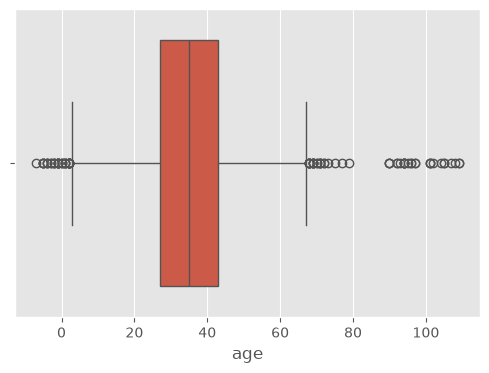

In [7]:
plt.figure(figsize=(6,4))

sns.boxplot(x=users["age"])

plt.show()

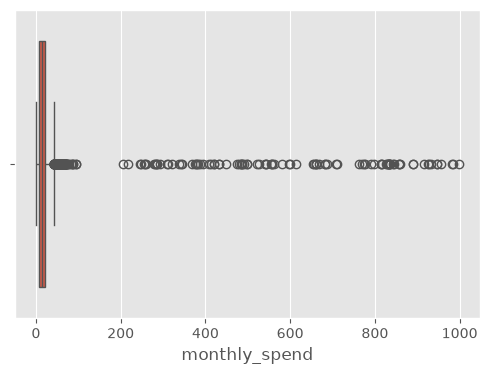

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x=users["monthly_spend"])
plt.show()

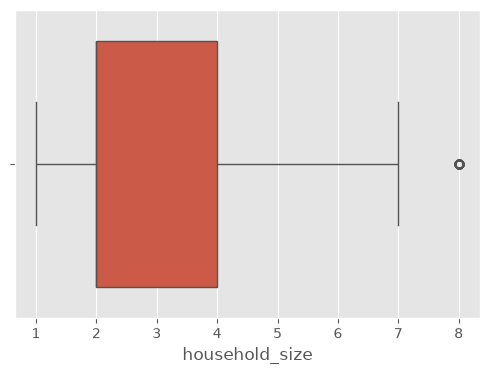

In [14]:
plt.figure(figsize=(6,4))
sns.boxplot(x=users["household_size"])
plt.show()

### Value Counts

In [8]:
users["subscription_plan"].value_counts()

subscription_plan
Standard    3625
Premium     3619
Basic       2020
Premium+    1036
Name: count, dtype: int64

In [9]:
users["country"].value_counts()

country
USA       7204
Canada    3096
Name: count, dtype: int64

In [10]:
watch["action"].value_counts()

action
started      26488
stopped      26266
paused       26217
completed    26029
Name: count, dtype: int64

### Relationship checks

In [11]:
watch["user_id"].isin(users["user_id"]).all()

np.True_

In [13]:
watch["movie_id"].isin(movies["movie_id"]).all()

np.True_

In [14]:
recommendations["user_id"].isin(users["user_id"]).all()

np.True_

In [15]:
recommendations["movie_id"].isin(movies["movie_id"]).all()

np.True_

In [16]:
search["user_id"].isin(users["user_id"]).all()

np.True_

In [17]:
reviews["user_id"].isin(users["user_id"]).all()

np.True_

In [18]:
reviews["movie_id"].isin(movies["movie_id"]).all()

np.True_

### Summary of Tables

In [5]:
users.describe()

,age,monthly_spend,household_size
count,9071.000000,9283.000000,8755.000000
mean,35.039466,22.146445,2.863392
std,12.580667,65.723824,1.563251
min,-7.000000,0.110000,1.000000
25%,27.000000,7.745000,2.000000
50%,35.000000,13.530000,2.000000
75%,43.000000,21.620000,4.000000
max,109.000000,997.800000,8.000000


In [10]:
unique_vals = users["subscription_plan"].unique()
print(unique_vals)

<StringArray>
['Basic', 'Premium+', 'Standard', 'Premium']
Length: 4, dtype: str
